In [1]:
!pip show imbalanced-learn

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,ConfusionMatrixDisplay,classification_report
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

from sklearn.tree import export_graphviz
from IPython.display import Image
#import graphviz
from astropy.cosmology import Planck18 as cosmo


In [26]:
ROOT_DIR = '/n/home06/jdecastro/ibn'
DATA_DIR =  os.path.join(ROOT_DIR, "data")
summary_file, = glob(os.path.join(DATA_DIR, "ZTFBTS_summary.csv"))
summary_data = pd.read_csv(summary_file)
summary_data.replace('-', np.nan, inplace=True)

In [27]:
DAYS_FROM_PEAK = None

print(f"SN_interpretable_params{'__'+str(DAYS_FROM_PEAK) if isinstance(DAYS_FROM_PEAK,(float,int)) else ''}.csv")

param_file, = glob(os.path.join(DATA_DIR, f"SN_interpretable_params{'__'+str(DAYS_FROM_PEAK) if isinstance(DAYS_FROM_PEAK,(float,int)) else ''}.csv"))
df = pd.read_csv(param_file)
# df = df[params_of_interest]

df
try:
    df = df.rename(columns={'oid':'supernova_name'})
    df = df.drop(['oid_r','oid_g'],axis=1)
except KeyError:
    pass

df['first_det'] = df[['first_det_r','first_det_g']].min(axis=1)

lookup_dict = dict(zip(summary_data['ZTFID'], summary_data['type'] == 'SN Ibn'))
z_dict = dict(zip(summary_data['ZTFID'], summary_data['redshift']))
type_dict = dict(zip(summary_data['ZTFID'], summary_data['type']))

df['Ibn'] = df['supernova_name'].map(lookup_dict)
df['redshift'] = df['supernova_name'].map(z_dict).astype(float)

df = df[~df['supernova_name'].map(type_dict).isnull()] # For now only labeled dataset
df.replace(-9999, np.nan, inplace=True)
null_counts = df.isnull().sum()

print(null_counts[null_counts>0])

SN_interpretable_params.csv
decline_slope_fixed_g      187
decline_slope_fixed_r      255
decline_slope_fixed_rg      94
decline_slope_g            378
decline_slope_r            435
decline_slope_rg           125
dm15_g                    2129
dm15_r                    1235
dm15_rg                    811
duration_g                  49
duration_r                  88
duration_rg                  8
last_nondet_g             1284
last_nondet_r             1048
last_nondet_rg             901
meandec_g                 8732
meandec_r                 8732
meandec_rg                8732
meanra_g                  8732
meanra_r                  8732
meanra_rg                 8732
peak_epoch_g                81
peak_epoch_r               112
peak_epoch_rg                9
peak_mag_g                  81
peak_mag_r                 112
peak_mag_rg                  9
rise_slope_g              2079
rise_slope_r              1808
rise_slope_rg             1443
rise_time_extrap_g        8483
rise_time_e

In [28]:

try:
    df = df.rename(columns={'oid':'supernova_name'})
    df = df.drop(['oid_r','oid_g'],axis=1)
except KeyError:
    pass

df['first_det'] = df[['first_det_r','first_det_g']].min(axis=1)
df['s0_r_log'] = np.log10(df['s0_r'] + 1)
df['s0_g_log'] = np.log10(df['s0_g'] + 1)

lookup_dict = dict(zip(summary_data['ZTFID'], summary_data['type'] == 'SN Ibn'))
z_dict = dict(zip(summary_data['ZTFID'], summary_data['redshift']))
type_dict = dict(zip(summary_data['ZTFID'], summary_data['type']))
print(set(type_dict.values()))

df['Ibn'] = df['supernova_name'].map(lookup_dict)
df['redshift'] = df['supernova_name'].map(z_dict).astype(float)

df = df[~df['supernova_name'].map(type_dict).isnull()] # For now only labeled dataset
print(f'Before redshift cut: {len(df)}')
df = df[~df['redshift'].isnull()]
df = df[df['redshift'] > 0]
print(f'After redshift cut {len(df)}')


slope_features = ['rise_slope_r','rise_slope_g','decline_slope_r','decline_slope_g','decline_slope_fixed_r','decline_slope_fixed_g']
dropped_features = ['meandec_g','meandec_r','meanra_g','meanra_r','last_nondet_g','last_nondet_r']
imputed_features = slope_features+['duration_r','rise_time_r','rise_time_g']+['s0_g','s0_r','s0_r_log','s0_g_log']+['peak_mag_r', 'peak_mag_g','first_det','first_det_g', 'first_det_r']+['color']+['decline_slope_ratio','rise_slope_ratio']
safe_features = [
       'ndetection_g', 'ndetection_r'] #+  [n+'_missing' for n in imputed_features]
cut_features = ['redshift']
'''

slope_features = ['rise_slope_r','rise_slope_g']
imputed_features = slope_features+['rise_time_r','rise_time_g']+['s0_g','s0_r','s0_r_log','s0_g_log']+['peak_mag_r', 'peak_mag_g','first_det','first_det_g', 'first_det_r']+['color']+['rise_slope_ratio']
dropped_features = ['meandec_g','meandec_r','meanra_g','meanra_r','last_nondet_g','last_nondet_r','rise_time_flag_r','rise_time_flag_g']
safe_features = []
cut_features = ['redshift']
'''
features = imputed_features + cut_features + safe_features

# Drop columns in droppped_features
df = df.drop(dropped_features,axis=1)

# Drop NaN values in cut features
df.replace(-9999, np.nan, inplace=True)

# MY FEATURE ENGINEERING PART

# Add color g - r

df['color'] = df['peak_mag_g'] - df['peak_mag_r']

# Correct to peak mag from redshift:

dL = cosmo.luminosity_distance(df['redshift']).to("pc").value
mu = 5 * np.log10(dL) - 5           
df['peak_mag_r'] = df['peak_mag_r'] - mu
df['peak_mag_g'] = df['peak_mag_g'] - mu

#df['peak_epoch_r'] = df['peak_epoch_r'] - df['first_det_r']
#df['peak_epoch_g'] = df['peak_epoch_g'] - df['first_det_g']
def is_reasonable(x):
    return np.isfinite(x) and -5 < x < 5  # example range

dsr_mask = (
    df['decline_slope_g'].apply(is_reasonable)
    & df['decline_slope_r'].apply(is_reasonable)
    & (df['decline_slope_r'] != 0)
)

rsr_mask = (
    df['decline_slope_g'].apply(is_reasonable)
    & df['decline_slope_r'].apply(is_reasonable)
    & (df['decline_slope_r'] != 0)
)


df['decline_slope_ratio'] = np.nan
df['decline_slope_ratio'] = df['decline_slope_g'] / df['decline_slope_r']
df['rise_slope_ratio'] = df['rise_slope_g'] / df['rise_slope_r']
'''
df.loc[dsr_mask, 'decline_slope_ratio'] = (
    df.loc[dsr_mask, 'decline_slope_g'] / df.loc[dsr_mask, 'decline_slope_r']
)
df['decline_slope_ratio'] = df['decline_slope_g'] / df['decline_slope_r']

df['rise_slope_ratio'] = np.nan
df.loc[rsr_mask, 'rise_slope_ratio'] = (
    df.loc[rsr_mask, 'rise_slope_g'] / df.loc[rsr_mask, 'rise_slope_r']
)
'''
#df['rest_rise_time_r'] = df['peak_epoch_r'] / (1 + df['redshift'])

#df['rest_rise_time_g'] = df['peak_epoch_g'] / (1 + df['redshift'])

import numpy as np

#columns_to_check = ['s0_r', 's0_g']

#for col in columns_to_check:
    #df[col] = df[col].where(df[col].between(-9000, 3), np.nan)
print(f'Before cut_features cut {len(df)}')
df = df.dropna(subset=cut_features)
print(f'After cut_features cut {len(df)}')

# Impute features in imputed_features
from sklearn.impute import SimpleImputer
for col in imputed_features:
    df[f'{col}_missing'] = df[col].isna().astype(int)
    
#all_nan_impute_cols = [c for c in imputed_features if not df[c].notna().any()]
#print(all_nan_impute_cols)

imputer = SimpleImputer(strategy='median')
df[imputed_features] = imputer.fit_transform(df[imputed_features])


print(len(df))
df.to_csv('test.csv')

{'SN Ia-SC', 'SN Iax', 'Ic-BL', 'SN IIP', 'ILRT', 'LBV', 'II?', 'IIn?', 'SN Icn', 'SN Ca-rich-Ca', 'UB;RL', 'SLSN-I', 'TDE-He', 'SN Ib/c', 'IIn/Ibn', 'SN II-pec', 'IIb', 'SN Ia-pec', 'Ib', 'SN Ib-pec', 'SN Ic-BL', 'Feat.', 'SN IIL', 'SN Ib', 'nova', 'SLSN-II', 'Feat.;RL', 'SN IIn', 'CV', 'SN Ia-91T', 'SN Ibn', 'SN Ia-CSM', 'Ca-rich', 'TDE', 'LRN', 'TDE-H-He', nan, 'SN II', 'SN IIb', 'SN Ia', 'Ic', 'SN Ia-91bg', 'SN Ic-pec', 'UB', 'Ibn', 'other', 'Other', 'II', 'SN IIn-pec', 'SN Ic'}
Before redshift cut: 8732
After redshift cut 8705
Before cut_features cut 8705
After cut_features cut 8705
8705


In [29]:
print(df[df['peak_epoch_r'] == df['peak_epoch_r'].min()][['peak_epoch_r']])

      peak_epoch_r
6025  54021.441015


In [30]:
prefixes = ['SN','AT', 'TD']
def strip_name(name):
    if name == '-':
        return None
    elif "".join(name[:2]) in prefixes:
        return name[2:]
    else:
        return name

'''ztf_to_name = {r['ZTFID']:strip_name(r['IAUID']) for _,r in summary_data.iterrows()}
ztf_names = [n for n in df['supernova_name']]
names = [ztf_to_name[z] for z in ztf_names]
print(names)'''

"ztf_to_name = {r['ZTFID']:strip_name(r['IAUID']) for _,r in summary_data.iterrows()}\nztf_names = [n for n in df['supernova_name']]\nnames = [ztf_to_name[z] for z in ztf_names]\nprint(names)"

In [31]:
df_ibn = df[df['supernova_name'].isin(summary_data[summary_data['type'] == 'SN Ibn']['ZTFID'])].copy()

# split by Ibn

df_rest = df[df['Ibn'] == False]
print('Before',len(df))
print('After',len(df_rest))
print('Ibn',len(df_ibn))

Before 8705
After 8662
Ibn 43


In [32]:
# Count NaN values per column
rest_nan_counts = df_rest.isnull().sum()

print('Non Ibn:')
for a,b in rest_nan_counts.items():
    print(a,b)

'''print('before',len(df_rest))
df_rest_filtered = df_rest[~((df_rest['last_nondet_g'].isnull()) | (df_rest['last_nondet_r'].isnull()))].copy() # drop where either last_nondet_r or last_nondet_g is null
print('after',len(df_rest_filtered))'''

# Count NaN values per column
ibn_nan_counts = df_ibn.isnull().sum()

print('Ibn:')
for a,b in ibn_nan_counts.items():
    print(a,b)

'''print('before',len(df_ibn))
df_ibn_filtered = df_ibn[~((df_ibn['last_nondet_g'].isnull()) | (df_ibn['last_nondet_r'].isnull()))].copy() # drop where either last_nondet_r or last_nondet_g is null
print('after',len(df_ibn_filtered))'''

# Removed the before and after since there were too many null nondets

df_rest_filtered = df_rest.copy()
df_ibn_filtered = df_ibn.copy()

Non Ibn:
supernova_name 0
decline_slope_fixed_g 0
decline_slope_fixed_r 0
decline_slope_fixed_rg 93
decline_slope_g 0
decline_slope_r 0
decline_slope_rg 125
dm15_g 2110
dm15_r 1213
dm15_rg 794
duration_g 49
duration_r 0
duration_rg 8
filt_g 0
filt_r 0
filt_rg 0
first_det_g 0
first_det_r 0
first_det_rg 0
gr_offset_used_rg 0
gr_pairs_used_rg 0
last_nondet_rg 888
meandec_rg 8662
meanra_rg 8662
ndetection_g 0
ndetection_r 0
ndetection_rg 0
peak_epoch_g 81
peak_epoch_r 112
peak_epoch_rg 9
peak_mag_g 0
peak_mag_r 0
peak_mag_rg 9
rise_slope_g 0
rise_slope_r 0
rise_slope_rg 1426
rise_time_extrap_g 8415
rise_time_extrap_r 8382
rise_time_extrap_rg 8577
rise_time_flag_g 1631
rise_time_flag_r 1533
rise_time_flag_rg 1416
rise_time_g 0
rise_time_method_g 8415
rise_time_method_r 8382
rise_time_method_rg 8577
rise_time_r 0
rise_time_rg 1416
s0_g 0
s0_r 0
s0_rg 1317
first_det 0
Ibn 0
redshift 0
s0_r_log 0
s0_g_log 0
color 0
decline_slope_ratio 0
rise_slope_ratio 0
rise_slope_r_missing 0
rise_slope_g_mi

In [33]:
df_rest_filtered['Ibn'] = 0
df_ibn_filtered['Ibn'] = 1

full = pd.concat([df_rest_filtered,df_ibn_filtered],ignore_index=True)
# 
#  = full.drop('supernova_name',axis=1)
# full['Ibn'] = full['Ibn'].map({True:1,False:0}) # Map from boolean to int

# full.drop(['log_jitter_r','log_jitter_r'],axis=1)

print(len(df_ibn_filtered))

43


(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.,   1.,   0.,   2.,   2.,   1.,   1.,   1.,  48., 135., 169.,
        225., 244., 272., 220., 222., 207., 196., 181., 224., 200., 203.,
        268., 330., 435., 751., 507., 628., 586., 541., 448., 333., 257.,
        179., 160., 115.,  94.,  77.,  58.,  50.,  33.,  26.,  23.,   8.,
         10.,   6.,   4.,   1.,   7.,   3.,   0.,   3.,   0.,   0.,   2.,
          0.,   1.,   0.,   1.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,
          1.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([-0.13090648, -0.12665567, -0.12240487, -0.11815407, -0.11390326,
        -0.10965246, -0.10540165, -0.10115085, -0.09690005, -0.09264924,
        -0.08839844, -0.08414764, -0.07989683, -0.07564603, -0.07139523,
        -0.06714442, -0.06289362, -0.05864282, -0.05439201, -0.05014121,
        -0.04589041, -0.04

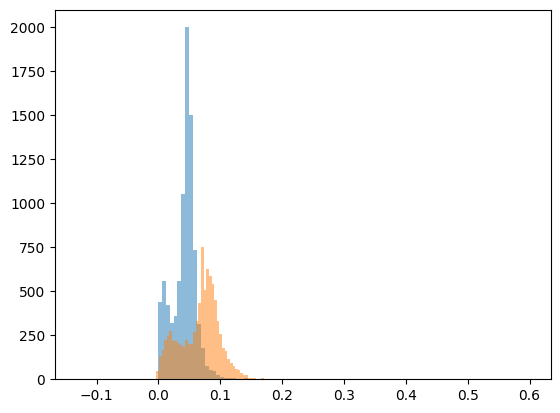

In [34]:
#plt.scatter(np.log(full['color']),np.log(full['decline_slope_ratio']),s=0.1)
#plt.ylim(-2,2)
#plt.hist(full['decline_slope_ratio'],bins=np.arange(0,5,0.1))
plt.hist(full['decline_slope_fixed_r'],bins=100,alpha=0.5)
plt.hist(full['decline_slope_fixed_g'],bins=100,alpha=0.5)

# check fits of max freq decline slopes

In [35]:
# Train Test Split
# full = full[['mean_g,']]
'''
X = full.drop('Ibn',axis=1)
y = full['Ibn']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.5,stratify=y,random_state=12282005)
print(X_train)
'''

unique_SN = full['supernova_name'].unique()


SN_to_type = dict(zip(full['supernova_name'], full['Ibn']))
types = [SN_to_type[SN] for SN in unique_SN]

train_SN,test_SN = train_test_split(unique_SN,stratify=types,test_size=0.4,random_state=12282005)

train_mask = full['supernova_name'].isin(train_SN)
test_mask = ~train_mask

bad_features = ['s0_r','s0_g','first_det_r','first_det_g','first_det','random_noise','decline_slope_r','decline_slope_g','dm15_r','dm15_g'] #['redshift','duration_g','peak_epoch_g','decline_slope_g','duration_r']

features = [f for f in features if f not in bad_features]

X_train = full[train_mask][features]
y_train = full[train_mask]['Ibn']

X_test = full[test_mask][features]
y_test = full[test_mask]['Ibn']
print(len(full),len(X_test))

8705 3482


In [36]:

'''
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# --- Inputs expected ---
# df: your original dataframe with a boolean/binary column 'Ibn'
# sampling_strategy: your desired SMOTE sampling strategy (e.g., 'auto' or {True: N})
# -----------------------

# Ensure boolean label
full['Ibn'] = full['Ibn'].astype(bool)

# Numeric feature columns (SMOTE requires numeric)
num_cols = features

X = full[num_cols].copy()
y = full['Ibn'].copy()

# Run SMOTE (generates synthetic samples for the minority class, presumably Ibn=True)
sm = SMOTE(random_state=12282005, sampling_strategy=1.0)
X_res, y_res = sm.fit_resample(X, y)

# Combine back into a dataframe
res = X_res.copy()
res['Ibn'] = y_res

# --- Mark which True Ibn rows are original vs SMOTE-synthetic ---
# Build a set of original True Ibn rows (rounded to avoid tiny float diffs)
orig_true = df.loc[df['Ibn'] == True, num_cols].round(10)
orig_true_tuples = set(map(tuple, orig_true.to_numpy()))

res_true = res.loc[res['Ibn'] == True].copy()
res_true_tuples = list(map(tuple, res_true[num_cols].round(10).to_numpy()))
is_synth = [t not in orig_true_tuples for t in res_true_tuples]

res_true['Origin'] = np.where(is_synth, 'SMOTE (synthetic True Ibn)', 'Original True Ibn')

# (Optional) If you have many columns, pick a subset for readability:
# cols_for_plot = num_cols.tolist()[:6]
cols_for_plot = ['decline_slope_fixed_r','peak_mag_r','decline_slope_ratio','color','duration_r','rise_slope_g']

# Pairplot: True Ibn only, colored by origin (original vs synthetic)
g = sns.pairplot(
    res_true.sort_values(by='Origin', ascending=False),
    vars=cols_for_plot,
    hue='Origin',
    hue_order=['Original True Ibn', 'SMOTE (synthetic True Ibn)'],
    corner=True,
    diag_kind=None
)

for i, y_var in enumerate(g.y_vars):
    for j, x_var in enumerate(g.x_vars):
        if x_var == y_var:
            g.axes[i, j].set_visible(False)

g.fig.suptitle('True Ibn: Original vs SMOTE-Synthetic', y=1.02)
plt.savefig('SMOTE.png')
'''

"\nimport numpy as np\nimport pandas as pd\nimport seaborn as sns\nimport matplotlib.pyplot as plt\nfrom imblearn.over_sampling import SMOTE\n\n# --- Inputs expected ---\n# df: your original dataframe with a boolean/binary column 'Ibn'\n# sampling_strategy: your desired SMOTE sampling strategy (e.g., 'auto' or {True: N})\n# -----------------------\n\n# Ensure boolean label\nfull['Ibn'] = full['Ibn'].astype(bool)\n\n# Numeric feature columns (SMOTE requires numeric)\nnum_cols = features\n\nX = full[num_cols].copy()\ny = full['Ibn'].copy()\n\n# Run SMOTE (generates synthetic samples for the minority class, presumably Ibn=True)\nsm = SMOTE(random_state=12282005, sampling_strategy=1.0)\nX_res, y_res = sm.fit_resample(X, y)\n\n# Combine back into a dataframe\nres = X_res.copy()\nres['Ibn'] = y_res\n\n# --- Mark which True Ibn rows are original vs SMOTE-synthetic ---\n# Build a set of original True Ibn rows (rounded to avoid tiny float diffs)\norig_true = df.loc[df['Ibn'] == True, num_cols].

Defining custom objective and evaluation

In [37]:
# OPTIMIZING FOR F BETA SCORE 

# Try to tune parameters using optuna

import optuna
from lightgbm import LGBMClassifier,early_stopping, log_evaluation
from sklearn.metrics import fbeta_score,f1_score#recall_score,precision_score
from sklearn.model_selection import train_test_split,StratifiedKFold,LeaveOneOut

import warnings
warnings.filterwarnings("ignore")

optuna.logging.set_verbosity(optuna.logging.FATAL)

from imblearn.over_sampling import SMOTE

alpha = 10 # 1/beta

full = full.drop_duplicates(subset=['supernova_name']).reset_index(drop=True)

X = full[features]
y = full['Ibn']

#X['random_noise'] = np.random.normal(loc=0.0, scale=1.0, size=X.shape[0])

# Define objective function for Optuna
def objective_fn(trial):
    sampling_strategy = 1.0

    threshold = 0.9 # changed
    #threshold = trial.suggest_uniform("threshold",0.1,0.99)

    #focal_obj  = focal_loss_lgb(alpha, gamma)
    #focal_eval = focal_loss_eval(alpha, gamma)

    n_estimators    = trial.suggest_int("n_estimators",212,1000)
    max_depth       = trial.suggest_int("max_depth", 4, 8)
    num_leaves      = trial.suggest_int("num_leaves", 8, min(2**max_depth, 32))
    min_child_samps = trial.suggest_int("min_child_samples", 5, 100)
    lr              = trial.suggest_loguniform("learning_rate", 1e-3, 1e-1)
    data_sample_strategy = trial.suggest_categorical('data_sample_strategy', ['bagging', 'goss'])
    lambda_l1 = trial.suggest_loguniform("lambda_l1", 0.0005, 5.0)

    params = dict(
    #metric=['binary_logloss'],
      #class_weight      = "balanced",
      max_depth         = max_depth,
      num_leaves        = num_leaves,
      min_child_samples = min_child_samps,
      learning_rate     = lr,
      n_estimators      = n_estimators,
      random_state      = 12282005,
      verbosity         = -1,
      data_sample_strategy = data_sample_strategy
    )

    # want to do training and validation over 5 different splits:
    #print(sum(y))

    splitting = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=12282005
    )
    #splitting = LeaveOneOut()
    pscores = []
    rscores = []

    sm = SMOTE(random_state=12282005,sampling_strategy=sampling_strategy)

    # We have to apply SMOTE within each fold so we start with X and y

    for train_idx,val_idx in splitting.split(X,y):
        X_train_fold,y_train_fold,X_val_fold,y_val_fold = X.iloc[train_idx],y.iloc[train_idx],X.iloc[val_idx],y.iloc[val_idx]

        X_train_fold_resampled,y_train_fold_resampled = sm.fit_resample(X_train_fold,y_train_fold)
        #X_train_fold_resampled,y_train_fold_resampled = X_train_fold,y_train_fold

        model = LGBMClassifier(**params)

        model.fit(
            X_train_fold_resampled, y_train_fold_resampled,
            eval_set=[(X_val_fold, y_val_fold)],
            callbacks=[early_stopping(10)]
        )

        y_probs = model.predict_proba(X_val_fold)[:, 1]
        y_pred = (y_probs >= threshold).astype(int) 
        #score = f1_score(y_test, y_pred, average='binary')  # Focus on class 1
        #score = fbeta_score(y_val_fold, y_pred, beta=1/alpha, pos_label=1, average='binary')  # Focus on class 1 (Ibn)
        P = fbeta_score(y_val_fold, y_pred,beta=1/2,pos_label=1,average='binary')
        R = recall_score(y_val_fold, y_pred,pos_label=1,average='binary')
        pscores.append(P)
        rscores.append(R)

    pscores_mean = np.mean(pscores)
    pscores_std  = np.std(pscores, ddof=1)
    rscores_mean = np.mean(rscores)
    pscores_std  = np.std(pscores, ddof=1)
    trial.set_user_attr('threshold', threshold)
    #trial.set_user_attr('alpha', alpha)
    #trial.set_user_attr('gamma', gamma)
    trial.set_user_attr('scores_std', float(pscores_std))
    return pscores_mean
    recall_floor = 0.45
    if rscores_mean < recall_floor:
        return -recall_floor + rscores_mean
        J = 10.0
        return pscores_mean - (recall_floor - rscores_mean) * J
    return pscores_mean

# Run Optuna optimization
study = optuna.create_study(direction='maximize')

study.optimize(objective_fn, n_trials=100, n_jobs=1, show_progress_bar=True)


# ---

  0%|          | 0/100 [00:00<?, ?it/s]

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[422]	valid_0's binary_logloss: 0.0356238
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[429]	valid_0's binary_logloss: 0.0278102
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[574]	valid_0's binary_logloss: 0.0170588
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[535]	valid_0's binary_logloss: 0.0109728
Training until validation scores don't improve for 10 rounds


Best trial: 0. Best value: 0.561459:   1%|          | 1/100 [00:03<05:48,  3.52s/it]

Early stopping, best iteration is:
[375]	valid_0's binary_logloss: 0.0262202
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[273]	valid_0's binary_logloss: 0.0857663
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[273]	valid_0's binary_logloss: 0.0781138
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[273]	valid_0's binary_logloss: 0.0721732
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[273]	valid_0's binary_logloss: 0.079209
Training until validation scores don't improve for 10 rounds


Best trial: 0. Best value: 0.561459:   2%|▏         | 2/100 [00:04<03:32,  2.17s/it]

...

Early stopping, best iteration is:
[173]	valid_0's binary_logloss: 0.0117683
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[105]	valid_0's binary_logloss: 0.0270319
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[183]	valid_0's binary_logloss: 0.0356449
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[149]	valid_0's binary_logloss: 0.0269924
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[198]	valid_0's binary_logloss: 0.0197708
Training until validation scores don't improve for 10 rounds


Best trial: 23. Best value: 0.596323:  99%|█████████▉| 99/100 [02:35<00:01,  1.09s/it]

Early stopping, best iteration is:
[265]	valid_0's binary_logloss: 0.0106571
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[141]	valid_0's binary_logloss: 0.0269575
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[219]	valid_0's binary_logloss: 0.0364881
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[223]	valid_0's binary_logloss: 0.0288487
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[315]	valid_0's binary_logloss: 0.0177636
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[319]	valid_0's binary_logloss: 0.0113908
Training until validation scores don't improve for 10 rounds


Best trial: 23. Best value: 0.596323: 100%|██████████| 100/100 [02:36<00:00,  1.57s/it]

Early stopping, best iteration is:
[244]	valid_0's binary_logloss: 0.026117


In [38]:
# Best params and model
print("Best trial:")
print(f"  Value: {study.best_trial.value}")
print(f"Standard Deviation: {study.best_trial.user_attrs['scores_std']}")
print(f"Threshold: {study.best_trial.user_attrs['threshold']}")
print(f"  Params: ")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")


Best trial:
  Value: 0.596322767012422
Standard Deviation: 0.20687391259128515
Threshold: 0.9
  Params: 
    n_estimators: 907
    max_depth: 6
    num_leaves: 24
    min_child_samples: 99
    learning_rate: 0.05922169038010656
    data_sample_strategy: goss
    lambda_l1: 0.0379541298011229


In [39]:
full['supernova_name']

0       ZTF21abdxhgv
1       ZTF21abrxwvv
2       ZTF20aadfyjl
3       ZTF19abxtdgh
4       ZTF20abfhzhm
            ...     
8700    ZTF21aabpnlm
8701    ZTF25aaaoxjm
8702    ZTF23abhtkba
8703          2019uo
8704         2019wep
Name: supernova_name, Length: 8705, dtype: object

In [40]:
from sklearn.model_selection import RepeatedStratifiedKFold
import joblib
from collections import Counter

best_model = None
best_precision = -np.inf

# assuming X.index holds your unique object names/IDs
oids = full['supernova_name'].to_numpy()

# 1) set up your counter
false_negative_counts = Counter()

best_params = study.best_trial.params

if not best_params.get('sampling_strategy'):
    best_params.update({
        'sampling_strategy':1.0
    })
    
if not best_params.get('threshold'):
    best_params.update({
        'threshold':0.85
    })


try:
    best_threshold = best_params.pop('threshold')  # Extract threshold separately
    print(best_threshold)
except KeyError:
    pass

try:
    sampling_strategy = best_params.pop('sampling_strategy')
    print(sampling_strategy)
except KeyError:
    pass

THRESHOLD = best_threshold

# 1) Reconstruct your best‐param model
best_params.update({
    #'class_weight': 'balanced',
    #'n_estimators':   789,
    #'random_state':   12282005,
    'verbosity':-1,
})

clf = LGBMClassifier(**best_params)
sm = SMOTE(random_state=12282005,sampling_strategy=sampling_strategy)


rskf = RepeatedStratifiedKFold(
    n_splits=3, 
    n_repeats=20, 
    random_state=1228200 
)

recalls, precisions, fprs,f1s = [], [], [],[]

sm = SMOTE(random_state=12282005,sampling_strategy=1.0)
best_params = study.best_trial.params

for train_idx, test_idx in rskf.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # SMOTE only on training
    X_res, y_res = sm.fit_resample(X_tr, y_tr)

    # train and threshold
    mdl = LGBMClassifier(**best_params,n_jobs=-1).fit(X_res, y_res)
    probs = mdl.predict_proba(X_te)[:,1]
    preds = (probs >= 0.87).astype(int) # change here

    # compute metrics
    r = recall_score(y_te, preds)
    p = precision_score(y_te, preds)
    f = f1_score(y_te,preds)
    tn, fp, fn, tp = confusion_matrix(y_te, preds).ravel()
    fpr = fp / (fp + tn)

    recalls.append(r)
    precisions.append(p)
    f1s.append(f)
    fprs.append(fpr)

    # Save the best model
    if p > best_precision:
        best_model = mdl
        best_precision = p
    # find the false negatives (true Ibn but predicted non-Ibn)
    fn_mask = (y_te.values == 1) & (preds == 0)
    for idx in test_idx[fn_mask]:
        false_negative_counts[oids[idx]] += 1

# 2) print the top offenders
print("Ibn objects most frequently misseind (false negatives):")
print([oid for oid,_ in false_negative_counts.most_common(100)])
for oid, cnt in false_negative_counts.most_common(100):
    print(f"  {oid:20s}  missed {cnt} times")
        
joblib.dump(best_model, "best_model.pkl")  # <-- save it

print("Recall   : mean=%0.3f  std=%0.3f" % (np.mean(recalls), np.std(recalls, ddof=1)))
print("Precision: mean=%0.3f  std=%0.3f" % (np.mean(precisions), np.std(precisions, ddof=1)))
print("FPR      : mean=%0.3f  std=%0.3f" % (np.mean(fprs), np.std(fprs, ddof=1)))

import pandas as pd
import os

# Define your output file
metrics_path = "FINAL_PEAK_NEW.csv"

row_to_save = {
    "days_from_peak": DAYS_FROM_PEAK,
    "threshold": THRESHOLD,
    "precision": np.mean(precisions),
    "precision_std": np.std(precisions, ddof=1),
    "recall": np.mean(recalls),
    "recall_std": np.std(recalls, ddof=1),
    "f1": np.mean(f1s),
    "f1_std": np.std(f1s, ddof=1),
}

# If file exists, load it and replace the row with the same 'days_after'
if os.path.exists(metrics_path):
    df = pd.read_csv(metrics_path)
    df = df[df["days_from_peak"] != DAYS_FROM_PEAK]  # Remove old entry if exists
    df = pd.concat([df, pd.DataFrame([row_to_save])], ignore_index=True)
else:
    df = pd.DataFrame([row_to_save])

# Sort by days_after
df = df.sort_values("days_from_peak").reset_index(drop=True)

# Save to CSV
df.to_csv(metrics_path, index=False)

print(f"Updated metrics written to {metrics_path}")

0.85
1.0
Ibn objects most frequently misseind (false negatives):
['ZTF20aalrqbu', '2010al', 'ZTF20abfadah', 'ZTF20abyznqs', 'ZTF24abiesnr', '2019wep', 'ZTF19abhcefa', 'ZTF22aawxlpc', '2014av', 'ZTF21aauvmck', 'ZTF23abjjrwv', 'ZTF22aaaepgu', 'ZTF21achujxq', 'ZTF21aatwkkt', 'ZTF21aabpnlm', 'ZTF19acmbekd', 'ZTF25aaompnz', 'ZTF23abprwou', 'ZTF23aakfysp', 'ZTF19aatmkll', 'ZTF22aahftli', 'ZTF23abngbvw', 'ZTF23abhtkba', 'ZTF19aadnxbh', '2024acyl', 'ZTF19abamqxo', '2018jmt', 'ZTF21abuvury', 'iPTF14aki', 'ZTF19aapfmki', '2021jpk', 'ZTF21aamobbh', '2015U', '2020nxt', '2019uo']
  ZTF20aalrqbu          missed 20 times
  2010al                missed 20 times
  ZTF20abfadah          missed 20 times
  ZTF20abyznqs          missed 20 times
  ZTF24abiesnr          missed 20 times
  2019wep               missed 20 times
  ZTF19abhcefa          missed 20 times
  ZTF22aawxlpc          missed 20 times
  2014av                missed 20 times
  ZTF21aauvmck          missed 20 times
  ZTF23abjjrwv          mi

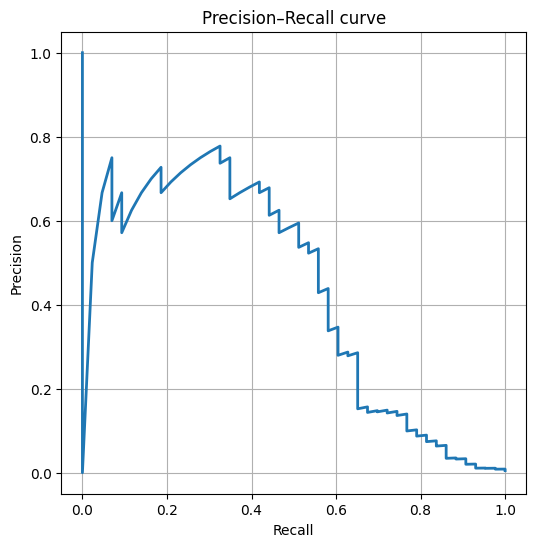

      rise_slope_r  rise_slope_g  decline_slope_fixed_r  \
0         0.080246      0.053913               0.033167   
1         0.000196      0.087492               0.042094   
2         0.100467      0.009279               0.044723   
3         0.189600      0.105624               0.045858   
4         0.140316      0.072749               0.057731   
...            ...           ...                    ...   
8700      0.172322      0.700600               0.056038   
8701      0.247287      0.225826               0.107261   
8702      0.345082      0.319446               0.142065   
8703      0.126519      0.096832               0.213899   
8704      0.082999      0.106804               0.074644   

      decline_slope_fixed_g  duration_r  rise_time_r  rise_time_g  s0_r_log  \
0                  0.045306   60.623432    27.263906    24.179239  0.044503   
1                  0.090820   26.436827    13.811505    13.776717  0.068617   
2                  0.063989   47.642806    15.266607  

In [41]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from imblearn.pipeline import make_pipeline

# define your CV
cv = StratifiedKFold(n_splits=3, random_state=12282005,shuffle=True)

# rebuild your pipeline/predictor with best_params & SMOTE inside
def make_model():
    return make_pipeline(
        SMOTE(random_state=12282005, sampling_strategy=sampling_strategy),
        LGBMClassifier(**best_params, n_jobs=-1)
    )

# `cross_val_predict` will train on each train‐fold, predict on that test‐fold, 
# and stitch back together into a single array `y_scores` aligned with X.
model = make_model()
y_scores = cross_val_predict(
    model, X, y, cv=cv, method='predict_proba'
)[:,1]

# now you have exactly one probability per sample
precision, recall, thresholds = precision_recall_curve(y, y_scores)

# and you can plot:
plt.figure(figsize=(6,6))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curve")
plt.grid(True)
plt.show()
print(X)
pd.concat([pd.DataFrame(X).reset_index(drop=True),
           pd.Series(y, name='y').reset_index(drop=True),
           pd.Series(y_scores, name='y_score').reset_index(drop=True)], axis=1)\
  .to_csv(f"pr__{DAYS_FROM_PEAK}.csv", index=False)


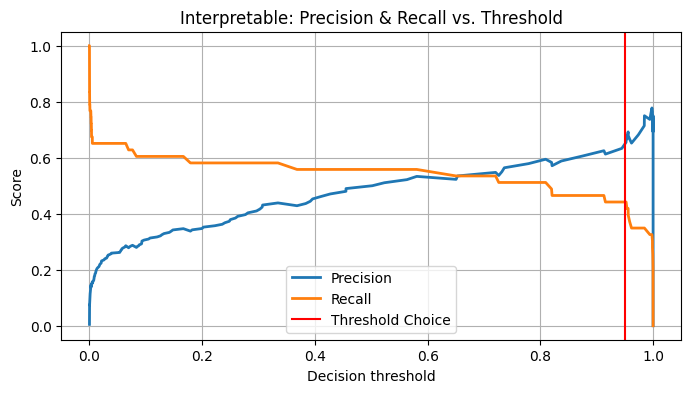

In [42]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# y_scores: one probability per sample, e.g. from cross_val_predict(...)
# y: the true binary labels

precision, recall, thresholds = precision_recall_curve(y, y_scores)

# precision and recall are length = len(thresholds)+1,
# so drop the last precision/recall that has no corresponding threshold
precision = precision[:-1]
recall    = recall[:-1]

plt.figure(figsize=(8,4))
plt.plot(thresholds, precision, label="Precision",  lw=2)
plt.plot(thresholds, recall,    label="Recall",     lw=2)
plt.axvline(x=0.95, color='r', label='Threshold Choice')
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Interpretable: Precision & Recall vs. Threshold")
plt.legend(loc="best")
plt.grid(True)
plt.show()


Gain: How much that feature reduced the loss function by

In [20]:
import eli5
from eli5.sklearn import PermutationImportance
from IPython.display import display

perm = PermutationImportance(best_model,scoring=None, n_iter=100, random_state=12282005, cv=None, refit=False).fit(X, y,)
tmp = eli5.show_weights(perm)
display(eli5.show_weights(perm, top = len(list(X.columns)), feature_names = list(X.columns)))

Weight,Feature
0.0072 ± 0.0014,color
0.0055 ± 0.0012,decline_slope_fixed_r
0.0032 ± 0.0012,decline_slope_ratio
0.0015 ± 0.0009,duration_r
0.0015 ± 0.0008,redshift
0.0013 ± 0.0005,ndetection_r
0.0011 ± 0.0006,rise_time_r
0.0011 ± 0.0006,rise_slope_ratio
0.0011 ± 0.0006,s0_r_log
0.0009 ± 0.0006,ndetection_g


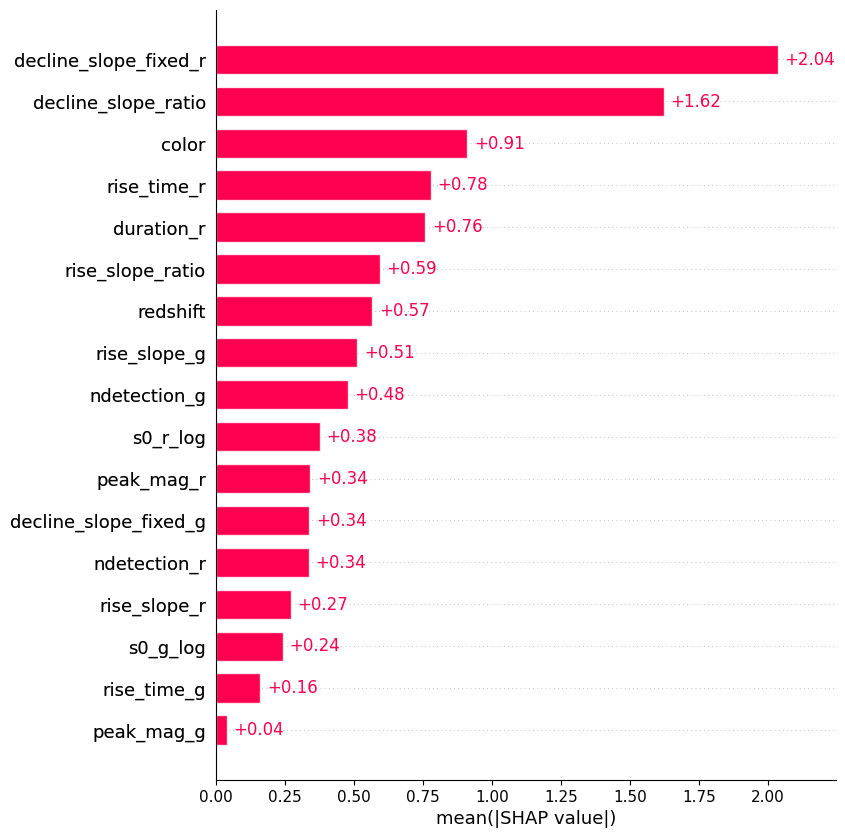

<Figure size 640x480 with 0 Axes>

In [21]:
import shap
n = X.shape[1]                     # how many features you have
saved_model = joblib.load("best_model.pkl") 
explainer = shap.Explainer(best_model)
shap_values = explainer(X)

shap.plots.bar(shap_values, max_display=n)        # global importance, all features
# or a beeswarm with all features:
#shap.plots.beeswarm(shap_values, max_display=n)
plt.savefig('INFEATS.png')

In [22]:
print(X.columns)

Index(['rise_slope_r', 'rise_slope_g', 'decline_slope_fixed_r',
       'decline_slope_fixed_g', 'duration_r', 'rise_time_r', 'rise_time_g',
       's0_r_log', 's0_g_log', 'peak_mag_r', 'peak_mag_g', 'color',
       'decline_slope_ratio', 'rise_slope_ratio', 'redshift', 'ndetection_g',
       'ndetection_r'],
      dtype='object')


In [23]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


Split Gain: How much that specific decision reduced the loss function by

Leaf Count: Number of rows/SN in that leaf

In [24]:
from lightgbm import plot_tree

plot_tree(lgbm, tree_index=0, figsize=(20, 10), show_info=['split_gain', 'internal_value', 'leaf_count'])
plt.title("LightGBM Tree #0")
plt.show()

NameError: name 'lgbm' is not defined

In [ ]:
def walk_tree(node, path=None):
    if path is None:
        path = []

    if 'split_index' in node:  # internal node
        feature = node['split_feature']
        threshold = node['threshold']
        gain = node['split_gain']
        left = node['left_child']
        right = node['right_child']

        # Add split to path and recurse
        walk_tree(left, path + [f"{feature} ≤ {threshold:.4f} (gain: {gain:.3f})"])
        walk_tree(right, path + [f"{feature} > {threshold:.4f} (gain: {gain:.3f})"])

    else:  # leaf node
        print(f"🟢 Leaf node:")
        print(f"   ➤ Path: {' → '.join(path)}")
        print(f"   ➤ Sample count: {node['leaf_count']}")
        print(f"   ➤ Internal value (log-odds): {node['leaf_value']:.4f}")
        print("")

# Load tree 0 from your model
tree_info = lgbm.booster_.dump_model()['tree_info'][0]
walk_tree(tree_info['tree_structure'])

In [ ]:
print(full[(full['duration_r'] < 0) & (full['duration_r'] > -100) & (full['Ibn'] == 1)])

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os
'''plt.plot([5,10,15,20],[0.1667,0.25,0.5556,0.6],label='Partial Light Curve Recall')
plt.plot([5,10,15,20],[0.72 for n in range(4)],label='Full Light Curve Recall')

plt.title('Recall for partial light curves (Interpretable Params)')
plt.legend()'''
plt.xlabel('Maximum Days After First Detection')
plt.ylabel('Recall for Ibn Class')
plt.ylim(0,1)

recall_data = pd.read_csv(os.path.join(DATA_DIR, "interpretable_results.csv"))
recall_data = recall_data[recall_data['metric']=='recall']

IN = recall_data[(recall_data['days_after']>0) & (recall_data['model'] == 'IN')]
NI = recall_data[(recall_data['days_after']>0) & (recall_data['model'] == 'NI')]

IN_row = recall_data[(recall_data['days_after'] == 0) & (recall_data['model'] == 'IN')].iloc[0]
NI_row = recall_data[(recall_data['days_after'] == 0) & (recall_data['model'] == 'NI')].iloc[0]

IN_full = IN_row['score']
IN_std = IN_row['std']

NI_full = NI_row['score']
NI_std = NI_row['std']

# Plot horizontal lines
plt.axhline(IN_full, label='Interpretable Full Light Curve Recall', color='green', linestyle='--')
plt.axhline(NI_full, label='Non-Interpretable Full Light Curve Recall', color='red', linestyle='--')

# Fill between for standard deviation
plt.fill_between(
    x=[0, max(recall_data['days_after'])],  # span full x-range
    y1=IN_full - IN_std,
    y2=IN_full + IN_std,
    color='green',
    alpha=0.2,
    label='Interpretable Full LC ±1σ'
)

plt.fill_between(
    x=[0, max(recall_data['days_after'])],
    y1=NI_full - NI_std,
    y2=NI_full + NI_std,
    color='red',
    alpha=0.2,
    label='Non-Interpretable Full LC ±1σ'
)
plt.errorbar(IN['days_after'],IN['score'],IN['std'],label='Interpretable Partial Light Curve Recall',color='green')
plt.errorbar(NI['days_after'],NI['score'],NI['std'],label='Non-Interpretable Partial Light Curve Recall',color='red')
plt.legend()
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)

plt.show()


In [ ]:
plt.plot([5,10,15,20],[155699,6589,67126,13884],label='Peak Epoch G')
plt.plot([5,10,15,20],[15419,9836,15906,3521],label='Peak Epoch R')
# plt.plot([5,10,15,20],[617,195743,8916556,216690],label='Decline Slope G')
plt.xlabel('Maximum Days After First Detection')
plt.ylabel('Feature Importance by Gain')
plt.title('Feature Importance Trend for Partial Light Curves')
plt.yscale('log')
plt.legend()

In [ ]:
plt.plot([5,10,15,20],[7038,353763,20846,94857],label='Decline Slope R')
plt.plot([5,10,15,20],[617,195743,8916556,216690],label='Decline Slope G')
plt.xlabel('Maximum Days After First Detection')
plt.ylabel('Feature Importance by Gain')
plt.title('Feature Importance Trend for Partial Light Curves')
plt.yscale('log')
plt.legend()

In [ ]:
print(full.columns)
full_with_type = full.copy()
full_with_type['type'] = full_with_type['supernova_name'].map(type_dict)
probs_full = lgbm.predict_proba(full_with_type[features])#[:, 1]
full_with_type['pred_prob'] = probs_full
plt.figure(figsize=(12,4))
full_with_type.boxplot(column='pred_prob', by='type', rot=60)
plt.axhline(best_threshold, ls='--')
plt.suptitle(''); plt.title('P(Ibn) distribution by spectroscopic type')

In [ ]:
import matplotlib.pyplot as plt

def plot_prob_hist(y_true, y_prob, bins=40):
    plt.figure()
    plt.hist(y_prob[y_true == 0], bins=bins, alpha=0.6, label='Not Ibn')
    plt.hist(y_prob[y_true == 1], bins=bins, alpha=0.6, label='Ibn')
    plt.axvline(best_threshold, ls='--')
    plt.xlabel('Predicted P(Ibn)')
    plt.ylabel('Count')
    plt.legend(); plt.title('Probability distribution by true label')


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 7))

# Filter valid probabilities
valid_probs = full_with_type[(full_with_type['pred_prob'] >= 0) & 
                             (full_with_type['pred_prob'] <= 1)]

types = valid_probs['type'].dropna().unique()

for t in types:
    subset = valid_probs[valid_probs['type'] == t]
    if len(subset) < 10:
        continue  # Skip types with too few examples to avoid scaling issues
    plt.hist(subset['pred_prob'],
             bins=np.linspace(0, 1, 100),
             density=True,
             alpha=0.6,
             label=f"{t} ({len(subset)})")

plt.xlabel('Predicted Probability of Ibn')
plt.ylabel('Density')
plt.title('Distribution of Predicted Probabilities by SN Type')
plt.legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(0, 1)  # Force x-axis from 0 to 1 explicitly
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
full_with_type[(full_with_type['pred_prob'] > 0.06) & (full_with_type['type'] !='SN Ibn')]

In [ ]:
cols_to_check = [
    'decline_slope_g', 'decline_slope_r',
    'duration_g', 'duration_r',
    'color',
    'first_det_g', 'first_det_r'
    # Add any other color/lightcurve features you've engineered
]

# Get the misclassified rows
misclassified = full_with_type[
    (full_with_type['pred_prob'] > 0.8) & (full_with_type['type'] != 'SN Ibn')
]

# Compare to Ibn examples
ibn = full_with_type[full_with_type['type'] == 'SN Ibn']
print(misclassified[cols_to_check].describe())
print(ibn[cols_to_check].describe())